# Regional Parallel Cell Coupling Demo

本 Notebook 演示如何把一个大容量电芯近似为三个相互独立、端电压相同的 1D 区域：

- **A - Corner**：拐角区域，占总面积 10%，假设更容易堵孔；
- **B - Middle**：大面中部，占总面积 70%；
- **C - Top**：顶部/极耳附近，占总面积 20%。

每个区域用一个 Thevenin 支路表示：

$$V_{cell}=E_k-I_kR_k, \qquad I_{total}=\sum_k I_k$$

其中放电电流取正。区域面积为 $f_k$ 时，基准电阻按 $R_k=R_{cell}/f_k$ 缩放，区域容量按 $Q_k=Q_{cell}f_kSOH_k$ 缩放。

> 当前版本是 **OCV + apparent resistance 的准静态耦合演示**，不是三套 PyBaMM DFN 的真正联立求解。它用于先验证“局部失效后电流转移到健康区域”这一关键机制。

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# 自动定位 workspace，避免依赖 Notebook 启动目录
search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
WORKSPACE_ROOT = next(root for root in search_roots if (root / "BatteryProject" / "src").exists())
PROJECT_ROOT = WORKSPACE_ROOT / "BatteryProject"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.simulation_regional_parallel as regional_module
importlib.reload(regional_module)

RegionalCellState = regional_module.RegionalCellState
build_area_scaled_regions = regional_module.build_area_scaled_regions
solve_parallel_current_split = regional_module.solve_parallel_current_split
aggregate_regional_capacity_ah = regional_module.aggregate_regional_capacity_ah

try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "no-latex"])
except ImportError:
    plt.style.use("default")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Calibri", "Microsoft YaHei", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.dpi": 110,
})
pd.set_option("display.float_format", lambda value: f"{value:,.6g}")

print(f"Workspace: {WORKSPACE_ROOT}")
print("Regional coupling module reloaded.")

Workspace: C:\HithiumSSD\hithium
Regional coupling module reloaded.


## 1. Input configuration

以下参数只用于展示耦合机制。`BASE_RESISTANCE_OHM` 表示健康整电芯的等效直流内阻；三个区域并联后应恢复该整电芯阻值。

In [2]:
AREA_FRACTIONS = {
    "A - Corner": 0.10,
    "B - Middle": 0.70,
    "C - Top": 0.20,
}
NOMINAL_CAPACITY_AH = 1175.0
BASE_OCV_V = 3.30
BASE_RESISTANCE_OHM = 0.00025  # 0.25 mOhm，演示值
TOTAL_CURRENT_A = 1175.0       # 约 1C 放电
VOLTAGE_CUTOFF_V = 2.50
PARTIAL_BLOCK_MULTIPLIER = 20.0
SWEEP_MULTIPLIERS = np.geomspace(1.0, 1000.0, 81)

config_df = pd.DataFrame({
    "Parameter": [
        "Nominal capacity", "Applied current", "Base OCV",
        "Healthy full-cell resistance", "Voltage cutoff",
    ],
    "Value": [
        NOMINAL_CAPACITY_AH, TOTAL_CURRENT_A, BASE_OCV_V,
        BASE_RESISTANCE_OHM * 1e6, VOLTAGE_CUTOFF_V,
    ],
    "Unit": ["A.h", "A", "V", "micro-ohm", "V"],
})
area_df = pd.DataFrame({
    "Region": list(AREA_FRACTIONS),
    "Area fraction": list(AREA_FRACTIONS.values()),
    "Nominal regional capacity [A.h]": [
        NOMINAL_CAPACITY_AH * fraction for fraction in AREA_FRACTIONS.values()
    ],
})
display(config_df)
display(area_df)

,Parameter,Value,Unit
0,Nominal capacity,"1,175",A.h
1,Applied current,"1,175",A
2,Base OCV,3.3,V
3,Healthy full-cell resistance,250,micro-ohm
4,Voltage cutoff,2.5,V


,Region,Area fraction,Nominal regional capacity [A.h]
0,A - Corner,0.1,117.5
1,B - Middle,0.7,822.5
2,C - Top,0.2,235


## 2. Healthy-state calculation

健康状态下三个区域 OCV 相同、材料性质相同，因此并联电流应按面积占比分配。下面同时检查：

- Kirchhoff current residual：$\sum I_k-I_{total}$；
- Equal-voltage residual：每个区域重构的 $E_k-I_kR_k$ 与公共端电压之差。

In [3]:
healthy_regions = build_area_scaled_regions(
    AREA_FRACTIONS,
    nominal_capacity_ah=NOMINAL_CAPACITY_AH,
    base_ocv_v=BASE_OCV_V,
    base_resistance_ohm=BASE_RESISTANCE_OHM,
)
healthy_result = solve_parallel_current_split(healthy_regions, TOTAL_CURRENT_A)

healthy_df = pd.DataFrame(healthy_result.rows())
healthy_df["current_share_pct"] = healthy_df["current_a"] / TOTAL_CURRENT_A * 100.0
healthy_df["reconstructed_voltage_v"] = (
    healthy_df["ocv_v"] - healthy_df["current_a"] * healthy_df["resistance_ohm"]
)
healthy_df["voltage_residual_v"] = (
    healthy_df["reconstructed_voltage_v"] - healthy_result.terminal_voltage_v
)

display(healthy_df[[
    "region", "area_fraction", "capacity_ah", "resistance_ohm",
    "current_a", "current_share_pct", "c_rate",
    "reconstructed_voltage_v", "voltage_residual_v",
]])

verification_df = pd.DataFrame({
    "Check": ["Common terminal voltage", "Current residual", "Max equal-voltage residual"],
    "Value": [
        healthy_result.terminal_voltage_v,
        sum(healthy_result.region_currents_a.values()) - TOTAL_CURRENT_A,
        healthy_df["voltage_residual_v"].abs().max(),
    ],
    "Unit": ["V", "A", "V"],
})
display(verification_df)

,region,area_fraction,capacity_ah,resistance_ohm,current_a,current_share_pct,c_rate,reconstructed_voltage_v,voltage_residual_v
0,A - Corner,0.1,117.5,0.0025,117.5,10,1,3.00625,0
1,B - Middle,0.7,822.5,0.000357143,822.5,70,1,3.00625,0
2,C - Top,0.2,235,0.00125,235,20,1,3.00625,0


,Check,Value,Unit
0,Common terminal voltage,3.00625,V
1,Current residual,-1.36424e-12,A
2,Max equal-voltage residual,0,V


## 3. Three representative states

- **Healthy**：三区域均正常；
- **A blocked x20**：只把拐角区域 A 的 apparent resistance 放大 20 倍；
- **A failed**：A 区容量归零并断开电流，B/C 承担全部外部电流。

In [4]:
scenario_specs = {
    "Healthy": {
        "resistance_multipliers": 1.0,
        "capacity_retention": 1.0,
        "current_bounds_a": None,
    },
    "A blocked x20": {
        "resistance_multipliers": {"A - Corner": 20.0, "B - Middle": 1.0, "C - Top": 1.0},
        "capacity_retention": 1.0,
        "current_bounds_a": None,
    },
    "A failed": {
        "resistance_multipliers": {"A - Corner": 1000.0, "B - Middle": 1.0, "C - Top": 1.0},
        "capacity_retention": {"A - Corner": 0.0, "B - Middle": 1.0, "C - Top": 1.0},
        "current_bounds_a": {"A - Corner": (0.0, 0.0)},
    },
}

scenario_results = {}
scenario_region_rows = []
scenario_summary_rows = []

for scenario, spec in scenario_specs.items():
    regions = build_area_scaled_regions(
        AREA_FRACTIONS,
        nominal_capacity_ah=NOMINAL_CAPACITY_AH,
        base_ocv_v=BASE_OCV_V,
        base_resistance_ohm=BASE_RESISTANCE_OHM,
        resistance_multipliers=spec["resistance_multipliers"],
        capacity_retention=spec["capacity_retention"],
        current_bounds_a=spec["current_bounds_a"],
    )
    result = solve_parallel_current_split(regions, TOTAL_CURRENT_A)
    scenario_results[scenario] = result

    total_capacity_ah = aggregate_regional_capacity_ah(regions)
    effective_resistance_ohm = (BASE_OCV_V - result.terminal_voltage_v) / TOTAL_CURRENT_A
    scenario_summary_rows.append({
        "scenario": scenario,
        "terminal_voltage_v": result.terminal_voltage_v,
        "effective_resistance_micro_ohm": effective_resistance_ohm * 1e6,
        "resistance_ratio_vs_healthy": effective_resistance_ohm / BASE_RESISTANCE_OHM,
        "remaining_capacity_ah": total_capacity_ah,
        "capacity_retention_pct": total_capacity_ah / NOMINAL_CAPACITY_AH * 100.0,
        "current_residual_a": sum(result.region_currents_a.values()) - TOTAL_CURRENT_A,
    })
    for row in result.rows():
        row = dict(row)
        row["scenario"] = scenario
        row["current_share_pct"] = row["current_a"] / TOTAL_CURRENT_A * 100.0
        scenario_region_rows.append(row)

scenario_summary_df = pd.DataFrame(scenario_summary_rows)
scenario_region_df = pd.DataFrame(scenario_region_rows)

display(scenario_summary_df)
display(scenario_region_df.pivot(index="scenario", columns="region", values="current_a"))

,scenario,terminal_voltage_v,effective_resistance_micro_ohm,resistance_ratio_vs_healthy,remaining_capacity_ah,capacity_retention_pct,current_residual_a
0,Healthy,3.00625,250,1,"1,175",100,-1.36424e-12
1,A blocked x20,2.97541,276.243,1.10497,"1,175",100,-6.82121e-13
2,A failed,2.97361,277.778,1.11111,"1,057.5",90,-4.54747e-13


region,A - Corner,B - Middle,C - Top
scenario,,,
A blocked x20,6.49171,908.84,259.669
A failed,0,913.889,261.111
Healthy,117.5,822.5,235


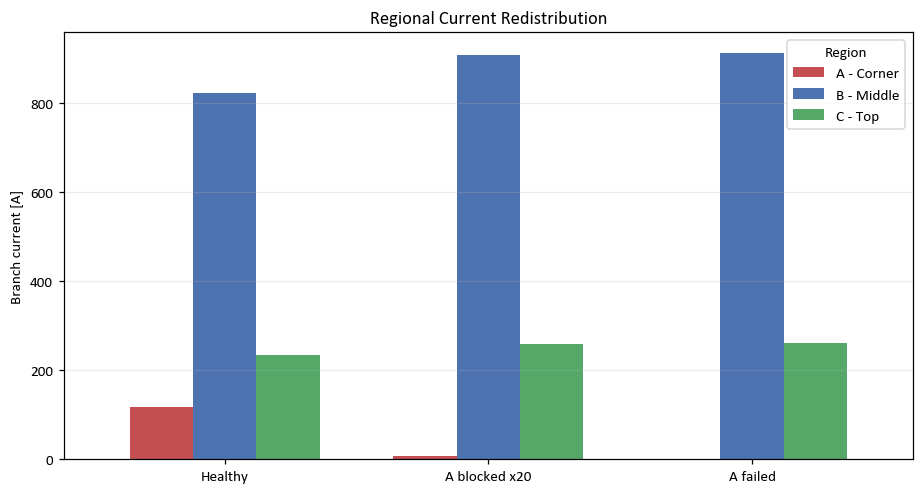

In [5]:
REGION_COLORS = {
    "A - Corner": "#C44E52",
    "B - Middle": "#4C72B0",
    "C - Top": "#55A868",
}

current_pivot = scenario_region_df.pivot(index="scenario", columns="region", values="current_a")
current_pivot = current_pivot.loc[list(scenario_specs)]

ax = current_pivot.plot(
    kind="bar",
    figsize=(8.5, 4.6),
    color=[REGION_COLORS[column] for column in current_pivot.columns],
    width=0.72,
)
ax.set_title("Regional Current Redistribution")
ax.set_xlabel("")
ax.set_ylabel("Branch current [A]")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Region", frameon=True)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Blockage sweep: local versus globally uniform degradation

同一个阻抗倍率 $m$ 用两种方式施加：

1. **Local blockage**：只有占比 10% 的 A 区阻抗乘以 $m$；
2. **Global uniform blockage**：A/B/C 所有区域阻抗都乘以 $m$，对应传统均匀 1D 模型把整电芯孔隙率一起压低的效果。

这正是本演示要观察的核心差异。

In [6]:
sweep_rows = []
for multiplier in SWEEP_MULTIPLIERS:
    local_regions = build_area_scaled_regions(
        AREA_FRACTIONS,
        nominal_capacity_ah=NOMINAL_CAPACITY_AH,
        base_ocv_v=BASE_OCV_V,
        base_resistance_ohm=BASE_RESISTANCE_OHM,
        resistance_multipliers={
            "A - Corner": multiplier,
            "B - Middle": 1.0,
            "C - Top": 1.0,
        },
    )
    global_regions = build_area_scaled_regions(
        AREA_FRACTIONS,
        nominal_capacity_ah=NOMINAL_CAPACITY_AH,
        base_ocv_v=BASE_OCV_V,
        base_resistance_ohm=BASE_RESISTANCE_OHM,
        resistance_multipliers=multiplier,
    )
    local_result = solve_parallel_current_split(local_regions, TOTAL_CURRENT_A)
    global_result = solve_parallel_current_split(global_regions, TOTAL_CURRENT_A)

    local_r = (BASE_OCV_V - local_result.terminal_voltage_v) / TOTAL_CURRENT_A
    global_r = (BASE_OCV_V - global_result.terminal_voltage_v) / TOTAL_CURRENT_A
    sweep_rows.append({
        "blockage_multiplier": multiplier,
        "local_terminal_voltage_v": local_result.terminal_voltage_v,
        "global_terminal_voltage_v": global_result.terminal_voltage_v,
        "local_resistance_ratio": local_r / BASE_RESISTANCE_OHM,
        "global_resistance_ratio": global_r / BASE_RESISTANCE_OHM,
        "A_current_share_pct": local_result.region_currents_a["A - Corner"] / TOTAL_CURRENT_A * 100.0,
        "B_current_share_pct": local_result.region_currents_a["B - Middle"] / TOTAL_CURRENT_A * 100.0,
        "C_current_share_pct": local_result.region_currents_a["C - Top"] / TOTAL_CURRENT_A * 100.0,
    })

sweep_df = pd.DataFrame(sweep_rows)
global_cutoff_rows = sweep_df[sweep_df["global_terminal_voltage_v"] <= VOLTAGE_CUTOFF_V]
local_cutoff_rows = sweep_df[sweep_df["local_terminal_voltage_v"] <= VOLTAGE_CUTOFF_V]

global_cutoff_multiplier = (
    float(global_cutoff_rows.iloc[0]["blockage_multiplier"]) if not global_cutoff_rows.empty else np.nan
)
local_cutoff_multiplier = (
    float(local_cutoff_rows.iloc[0]["blockage_multiplier"]) if not local_cutoff_rows.empty else np.nan
)

display(sweep_df.iloc[[0, 8, 20, 40, 60, 80]])
print(f"Global uniform model first crosses {VOLTAGE_CUTOFF_V:.2f} V near multiplier = {global_cutoff_multiplier:.3g}")
print(f"Local 10% blockage crosses cutoff in sweep: {np.isfinite(local_cutoff_multiplier)}")

,blockage_multiplier,local_terminal_voltage_v,global_terminal_voltage_v,local_resistance_ratio,global_resistance_ratio,A_current_share_pct,B_current_share_pct,C_current_share_pct
0,1,3.00625,3.00625,1,1,10,70,20
8,1.99526,2.99083,2.71389,1.0525,1.99526,5.275,73.675,21.05
20,5.62341,2.97994,1.64812,1.08958,5.62341,1.93758,76.2708,21.7916
40,31.6228,2.97475,-5.98919,1.10722,31.6228,0.350134,77.5055,22.1444
60,177.828,2.97381,-48.937,1.11042,177.828,0.0624434,77.7292,22.2083
80,"1,000",2.97365,-290.45,1.11099,"1,000",0.0111099,77.7691,22.2198


Global uniform model first crosses 2.50 V near multiplier = 2.82
Local 10% blockage crosses cutoff in sweep: False


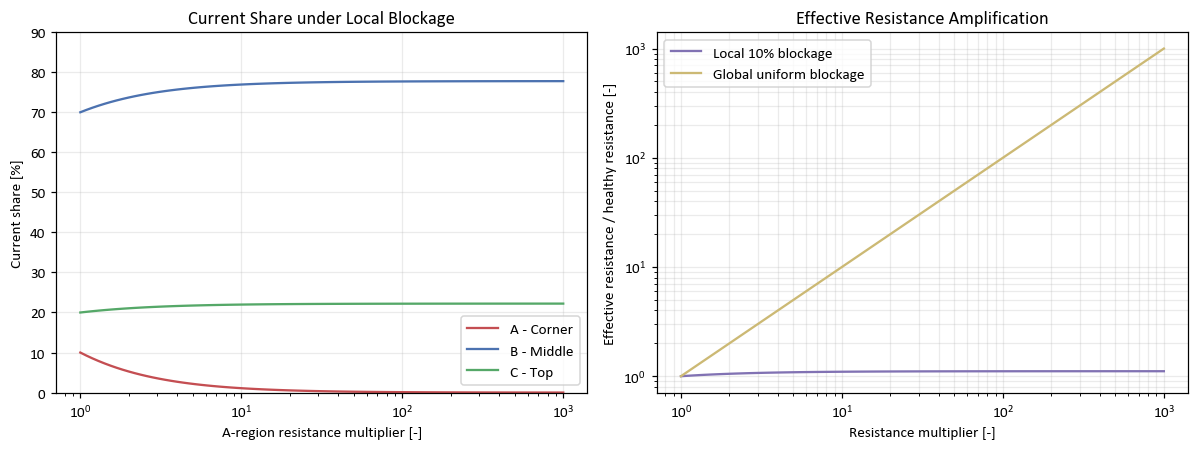

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))

axes[0].semilogx(
    sweep_df["blockage_multiplier"], sweep_df["A_current_share_pct"],
    color=REGION_COLORS["A - Corner"], label="A - Corner",
)
axes[0].semilogx(
    sweep_df["blockage_multiplier"], sweep_df["B_current_share_pct"],
    color=REGION_COLORS["B - Middle"], label="B - Middle",
)
axes[0].semilogx(
    sweep_df["blockage_multiplier"], sweep_df["C_current_share_pct"],
    color=REGION_COLORS["C - Top"], label="C - Top",
)
axes[0].set_title("Current Share under Local Blockage")
axes[0].set_xlabel("A-region resistance multiplier [-]")
axes[0].set_ylabel("Current share [%]")
axes[0].set_ylim(0, 90)
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=True)

axes[1].loglog(
    sweep_df["blockage_multiplier"], sweep_df["local_resistance_ratio"],
    color="#8172B3", label="Local 10% blockage",
)
axes[1].loglog(
    sweep_df["blockage_multiplier"], sweep_df["global_resistance_ratio"],
    color="#CCB974", label="Global uniform blockage",
)
axes[1].set_title("Effective Resistance Amplification")
axes[1].set_xlabel("Resistance multiplier [-]")
axes[1].set_ylabel("Effective resistance / healthy resistance [-]")
axes[1].grid(alpha=0.25, which="both")
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

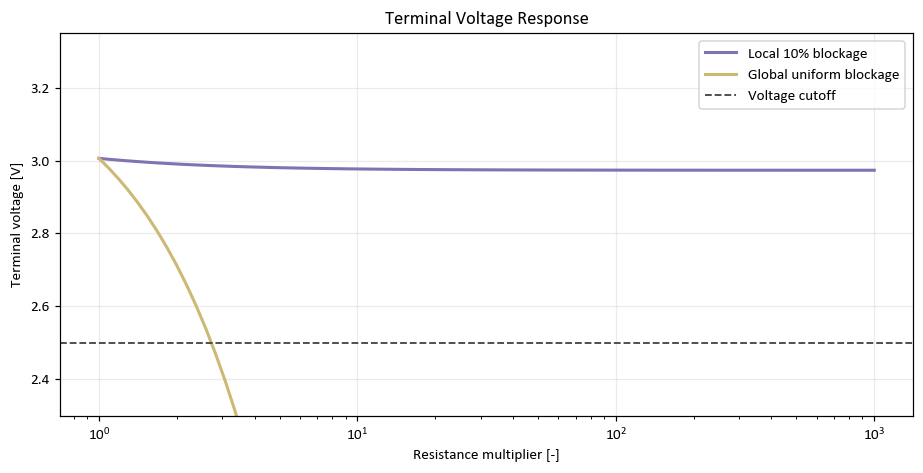

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.semilogx(
    sweep_df["blockage_multiplier"], sweep_df["local_terminal_voltage_v"],
    color="#8172B3", lw=2.0, label="Local 10% blockage",
)
ax.semilogx(
    sweep_df["blockage_multiplier"], sweep_df["global_terminal_voltage_v"],
    color="#CCB974", lw=2.0, label="Global uniform blockage",
)
ax.axhline(VOLTAGE_CUTOFF_V, color="#444444", ls="--", lw=1.2, label="Voltage cutoff")
ax.set_title("Terminal Voltage Response")
ax.set_xlabel("Resistance multiplier [-]")
ax.set_ylabel("Terminal voltage [V]")
ax.set_ylim(2.30, 3.35)
ax.grid(alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## 5. Postprocessing summary

下面把图中的关键量压缩成可以直接用于汇报的指标。

In [9]:
healthy = scenario_summary_df.set_index("scenario").loc["Healthy"]
blocked = scenario_summary_df.set_index("scenario").loc["A blocked x20"]
failed = scenario_summary_df.set_index("scenario").loc["A failed"]

healthy_a_current = scenario_region_df.query("scenario == 'Healthy' and region == 'A - Corner'")["current_a"].iloc[0]
blocked_a_current = scenario_region_df.query("scenario == 'A blocked x20' and region == 'A - Corner'")["current_a"].iloc[0]
failed_capacity_loss_pct = 100.0 - failed["capacity_retention_pct"]
local_limit_ratio = sweep_df["local_resistance_ratio"].iloc[-1]

postprocess_summary = pd.DataFrame({
    "Metric": [
        "Healthy terminal voltage",
        "A current reduction at x20 blockage",
        "Terminal voltage change at x20 blockage",
        "Capacity loss when A fully fails",
        "Local effective resistance ratio at x1000",
        "Global model cutoff multiplier",
    ],
    "Value": [
        healthy["terminal_voltage_v"],
        (1.0 - blocked_a_current / healthy_a_current) * 100.0,
        blocked["terminal_voltage_v"] - healthy["terminal_voltage_v"],
        failed_capacity_loss_pct,
        local_limit_ratio,
        global_cutoff_multiplier,
    ],
    "Unit": ["V", "%", "V", "%", "-", "-"],
})
display(postprocess_summary)

print(
    "Interpretation: the 10% corner region can become nearly inactive while the remaining 90% "
    "still supports the common terminal voltage. The uniform model instead applies the resistance "
    "penalty to the entire cell and reaches the cutoff much earlier."
)

,Metric,Value,Unit
0,Healthy terminal voltage,3.00625,V
1,A current reduction at x20 blockage,94.4751,%
2,Terminal voltage change at x20 blockage,-0.0308356,V
3,Capacity loss when A fully fails,10,%
4,Local effective resistance ratio at x1000,1.11099,-
5,Global model cutoff multiplier,2.81838,-


Interpretation: the 10% corner region can become nearly inactive while the remaining 90% still supports the common terminal voltage. The uniform model instead applies the resistance penalty to the entire cell and reaches the cutoff much earlier.


## 6. Interpretation and next boundary

本演示验证了预期机制：

- 当 A 区堵孔、阻抗升高时，A 区电流逐渐转移到 B/C 区；
- A 区完全失效时，模型主要表现为约 10% 的容量损失，同时健康区域维持公共端电压；
- 均匀 1D 模型把阻抗惩罚施加到全电芯，因此会过早预测整体极化抬升和电压跳水。

当前模型仍有明确边界：

- `OCV + apparent resistance` 不包含浓差极化、颗粒扩散、电解液动态和热耦合；
- 区域 OCV、阻抗和容量目前由外部给定，不会随 PyBaMM 老化状态自动更新；
- 真正的 314Ah DFN 分布耦合需要每个区域独立保存 PyBaMM state，并在每个 macro step 内迭代电流分配直到公共端电压收敛。

下一阶段应保持相同的外层接口，把这里的 `RegionalCellState` 数据来源替换成三套 314Ah DFN 的实时输出。